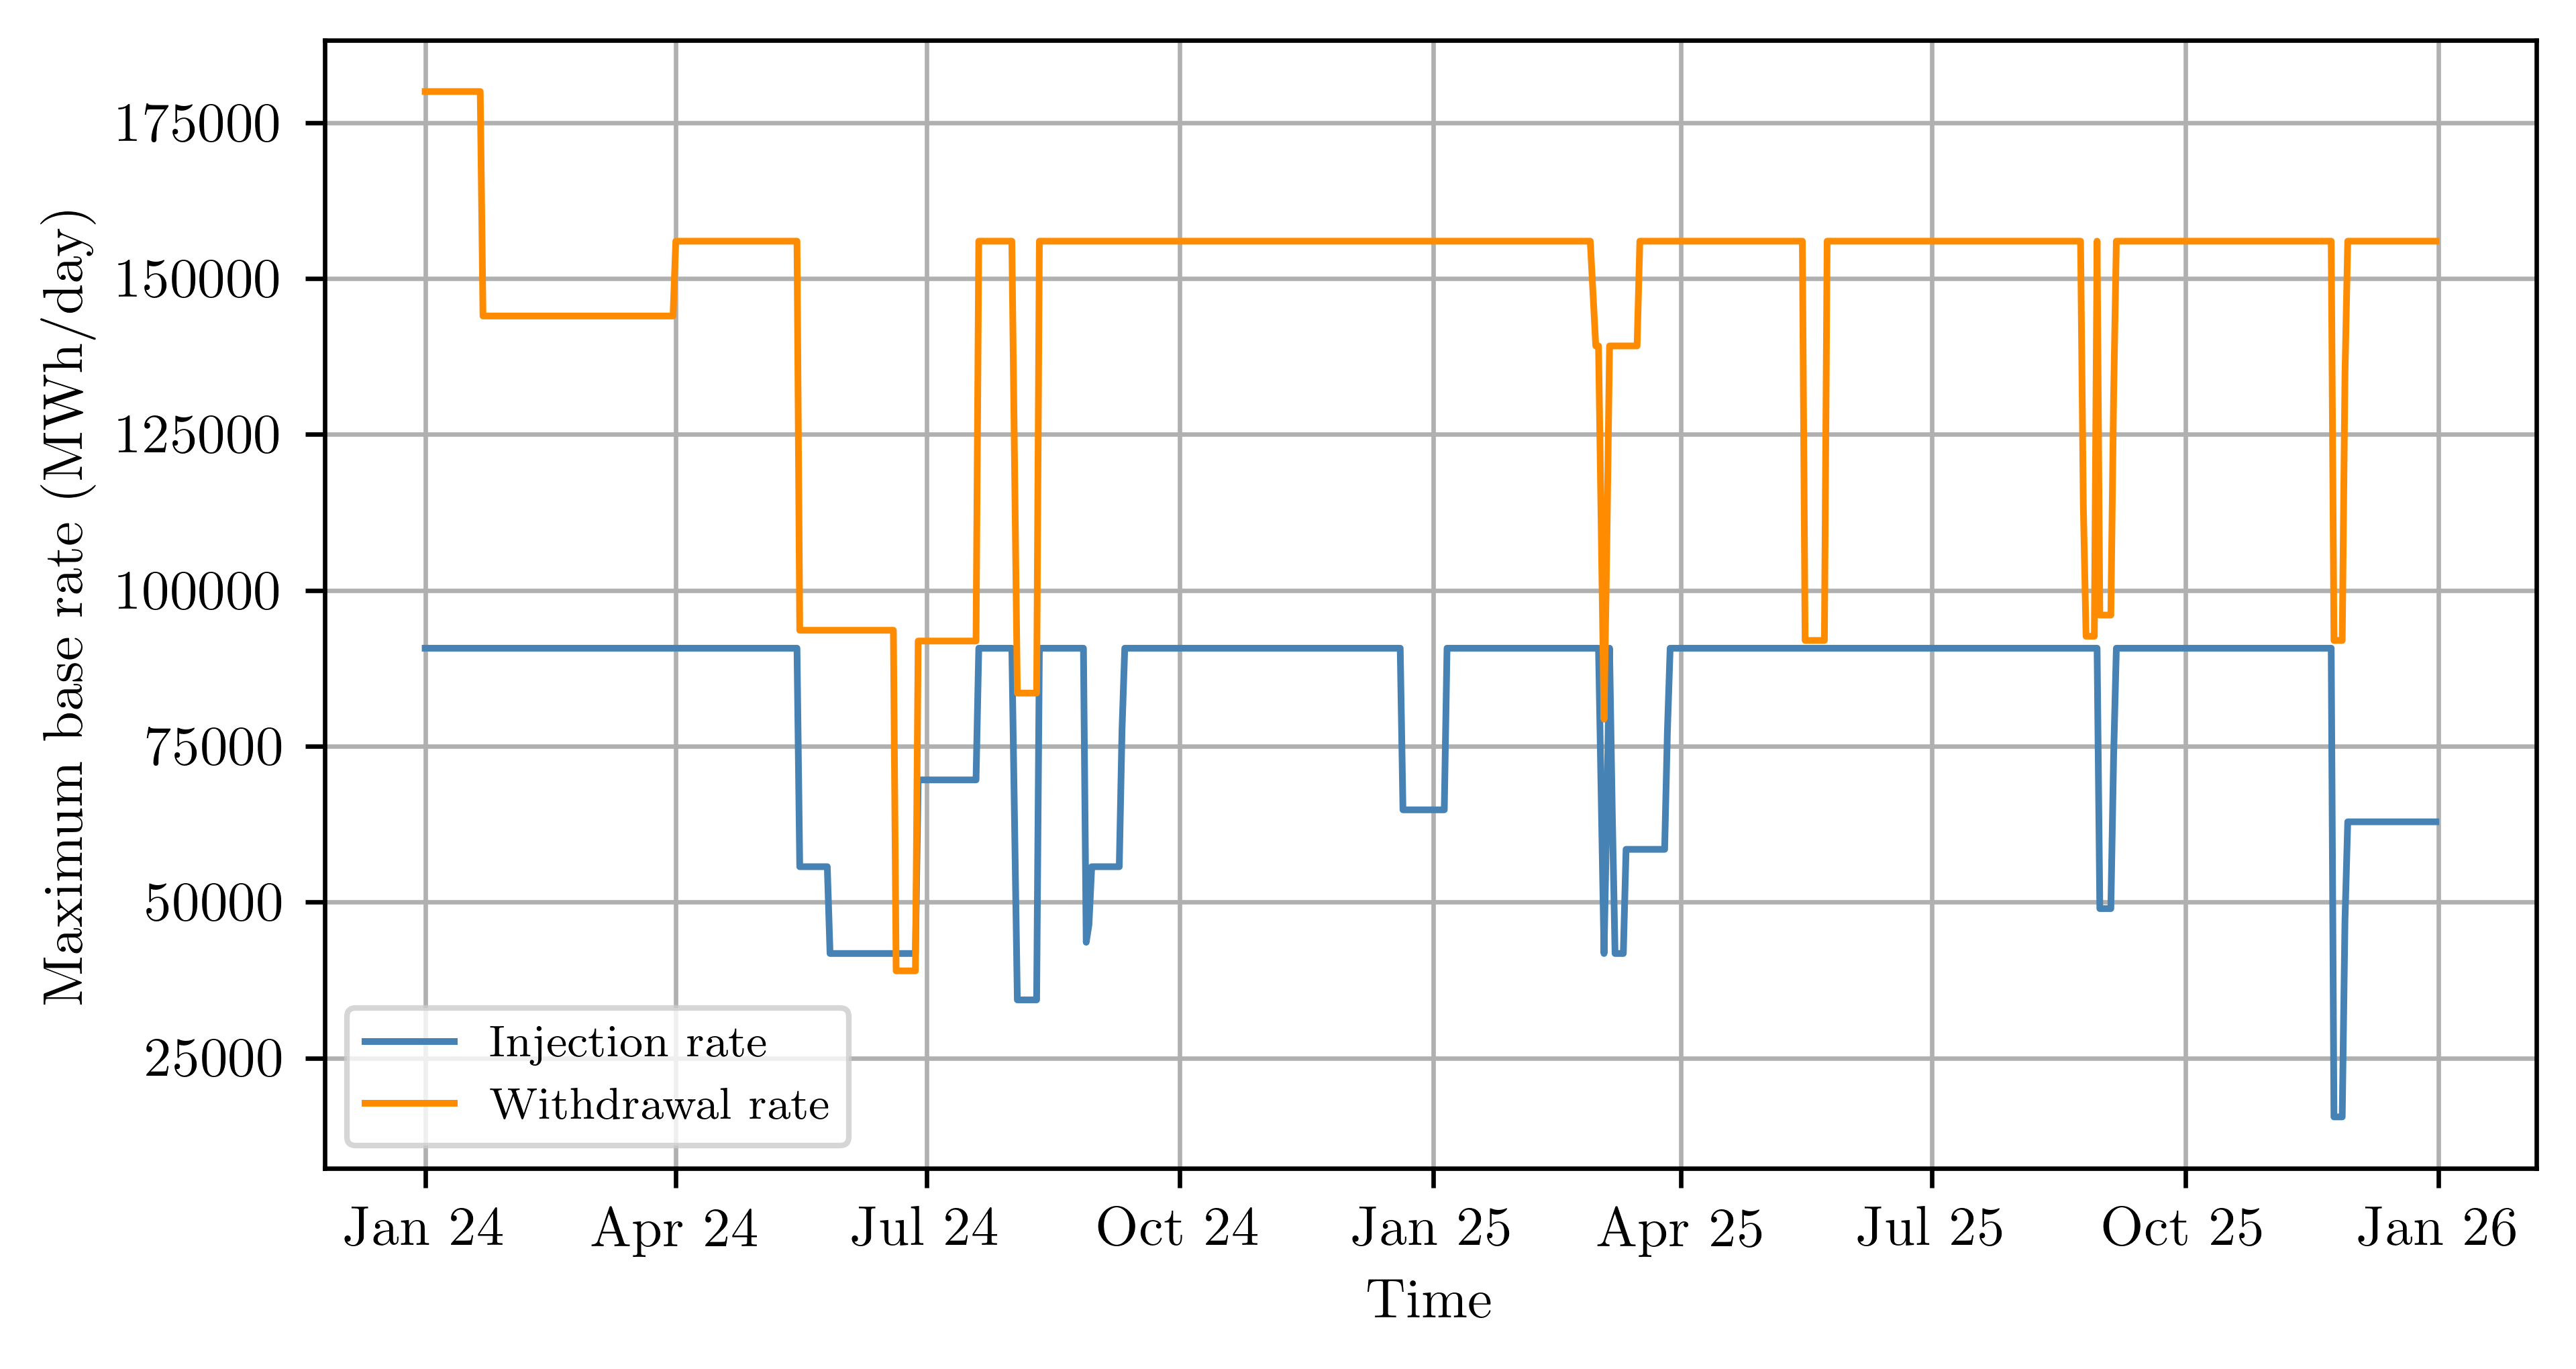

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import numpy as np
import pandas as pd

# ---- Load data ----
data_ir = pd.read_excel("../data/storage_utilization_IR.xlsx")
data_wr = pd.read_excel("../data/storage_utilization_WR.xlsx")

# ---- Format dates ----
for df in [data_ir, data_wr]:
    df["Gas Day"] = pd.to_datetime(df["Gas Day"])
    df = df.sort_values("Gas Day")

# ---- Restrict period ----
start_date = "2024-01-01"
end_date   = "2025-12-31"

data_ir = data_ir[(data_ir["Gas Day"] >= start_date) & (data_ir["Gas Day"] <= end_date)]
data_wr = data_wr[(data_wr["Gas Day"] >= start_date) & (data_wr["Gas Day"] <= end_date)]

# ---- Merge on Gas Day ----
data = pd.merge(
    data_ir,
    data_wr,
    on="Gas Day",
    how="inner",
    suffixes=("_IR", "_WR")
)

# ---- Plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Plot both series
ax.plot(data["Gas Day"], data["EXPECTED AVAILABLE IR"], 
        color="steelblue", lw=1.2, label="Injection rate")

ax.plot(data["Gas Day"], data["EXPECTED AVAILABLE WR"], 
        color="darkorange", lw=1.2, label="Withdrawal rate")

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh/day)")
ax.grid(True)

# ---- Ticks ----
tick_dates = pd.date_range(start=data["Gas Day"].min(),
                           end=data["Gas Day"].max() + pd.DateOffset(months=1),
                           freq="3MS")

ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.legend(loc="lower left", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/GSD_base_IR_WR_constraints.png")
plt.show()